<a href="https://colab.research.google.com/github/angelolucero-cloud/GO-Grupo-2/blob/main/Parte-B/Entrega1_ParteB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 1 — Parte B: Pronóstico

## 1. Diagnóstico documentado de las nueve series

Se examinarán tendencia, estacionalidad, valores atípicos, faltantes,
quiebres estructurales, intermitencia y promociones. Para cada anomalía
detectada se documentará el método de detección, su interpretación
y el tratamiento aplicado.

In [2]:
from pathlib import Path
import subprocess

carpeta_proyecto = Path("/content/GO-Grupo-2")

if not carpeta_proyecto.exists():
    subprocess.run(
        ["git", "clone",
         "https://github.com/angelolucero-cloud/GO-Grupo-2.git",
         str(carpeta_proyecto)],
        check=True
    )

print("Repositorio disponible en Colab.")

Repositorio disponible en Colab.


In [3]:
import pandas as pd
from IPython.display import display

ruta_datos = carpeta_proyecto / "datos"

demanda_original = pd.read_csv(ruta_datos / "demanda_semanal.csv")
maestro_original = pd.read_csv(ruta_datos / "maestro_sku.csv")

print("Primeras cinco filas de las ventas semanales:")
display(demanda_original.head())

print("Información de los productos:")
display(maestro_original)

print("Filas de ventas:", len(demanda_original))
print("Productos distintos:", demanda_original["sku"].nunique())
print("Semanas distintas:", demanda_original["semana"].nunique())

Primeras cinco filas de las ventas semanales:


,semana,fecha_lunes,anio_iso,semana_iso,sku,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
0,1,2023-10-02,2023,40,NEC-D05,1209.0,0.0,0,6620,6620
1,2,2023-10-09,2023,41,NEC-D05,1095.0,0.0,0,6620,6620
2,3,2023-10-16,2023,42,NEC-D05,1345.0,0.0,0,6620,6620
3,4,2023-10-23,2023,43,NEC-D05,1888.0,0.0,1,6620,4819
4,5,2023-10-30,2023,44,NEC-D05,991.0,0.0,0,6620,6620


Información de los productos:


,sku,familia,nombre_familia,sabor,formato_L,botellas_por_caja,litros_por_caja,linea_envasado,tasa_envasado_cajas_h,costo_variable_caja_clp,precio_lista_caja_clp,costo_inventario_caja_semana_clp,penalidad_atraso_caja_semana_clp
0,NEC-D05,NEC,Nectares con pulpa,Durazno,0.5,12,6.0,L1,180,3840,6620,95,1400
1,NEC-D15,NEC,Nectares con pulpa,Durazno,1.5,6,9.0,L2,210,5760,9930,95,1400
2,NEC-D30,NEC,Nectares con pulpa,Durazno,3.0,4,12.0,L2,130,7680,13240,95,1400
3,CIT-L05,CIT,Citricos gasificados,Limon,0.5,12,6.0,L1,180,2820,5320,95,1400
4,CIT-L15,CIT,Citricos gasificados,Limon,1.5,6,9.0,L2,210,4230,7980,95,1400
5,CIT-L30,CIT,Citricos gasificados,Limon,3.0,4,12.0,L2,130,5640,10640,95,1400
6,FUN-B05,FUN,Funcionales,Berries,0.5,12,6.0,L1,180,4860,9920,95,1400
7,FUN-B15,FUN,Funcionales,Berries,1.5,6,9.0,L2,210,7290,14880,95,1400
8,FUN-B30,FUN,Funcionales,Berries,3.0,4,12.0,L2,130,9720,19840,95,1400


Filas de ventas: 1404
Productos distintos: 9
Semanas distintas: 156


### 1.1. Revisión inicial de los datos

Se revisan fechas, tipos de datos, valores faltantes, registros duplicados,
continuidad semanal y consistencia de las variables. Los datos originales
se conservan sin modificaciones.

In [4]:
# Trabajamos con copias para conservar los datos originales.
demanda = demanda_original.copy()
maestro = maestro_original.copy()

# Convertimos las fechas. Las fechas que no se puedan interpretar
# quedarán marcadas como NaT.
demanda["fecha_lunes"] = pd.to_datetime(
    demanda["fecha_lunes"], errors="coerce"
)

print("1. TIPOS DE DATOS")
display(demanda.dtypes.rename("tipo").to_frame())

print("2. VALORES FALTANTES POR COLUMNA")
display(demanda.isna().sum().rename("faltantes").to_frame())

print("3. REGISTROS DUPLICADOS")
print("Filas completamente repetidas:",
      demanda_original.duplicated().sum())

duplicados = demanda.duplicated(
    subset=["sku", "semana"], keep=False
)
print("Filas con combinación SKU-semana repetida:",
      duplicados.sum())

if duplicados.any():
    display(demanda.loc[duplicados].sort_values(["sku", "semana"]))

print("4. COBERTURA POR PRODUCTO")
resumen = demanda.groupby("sku").agg(
    registros=("semana", "size"),
    semanas_distintas=("semana", "nunique"),
    primera_fecha=("fecha_lunes", "min"),
    ultima_fecha=("fecha_lunes", "max")
)
display(resumen)

print("5. CONTINUIDAD SEMANAL")
calendario = pd.date_range(
    demanda["fecha_lunes"].min(),
    demanda["fecha_lunes"].max(),
    freq="7D"
)

revision_calendario = []

for sku, grupo in demanda.groupby("sku"):
    fechas = pd.DatetimeIndex(grupo["fecha_lunes"].dropna().unique())
    faltantes = calendario.difference(fechas)

    revision_calendario.append({
        "sku": sku,
        "fechas_invalidas_o_faltantes": grupo["fecha_lunes"].isna().sum(),
        "fechas_que_no_son_lunes":
            (grupo["fecha_lunes"].dropna().dt.dayofweek != 0).sum(),
        "semanas_ausentes": len(faltantes)
    })

display(pd.DataFrame(revision_calendario).set_index("sku"))

print("6. CONSISTENCIA DE LAS VARIABLES")

controles = pd.Series({
    "Ventas negativas":
        (demanda["ventas_cajas"] < 0).sum(),
    "Días sin stock fuera del rango 0 a 7":
        (~demanda["dias_sin_stock"].between(0, 7)
         & demanda["dias_sin_stock"].notna()).sum(),
    "Promoción distinta de 0 o 1":
        (~demanda["promocion"].isin([0, 1])
         & demanda["promocion"].notna()).sum(),
    "Precio de lista menor o igual a cero":
        (demanda["precio_lista_clp"] <= 0).sum(),
    "Precio efectivo menor o igual a cero":
        (demanda["precio_efectivo_clp"] <= 0).sum(),
    "Precio efectivo mayor que el de lista":
        (demanda["precio_efectivo_clp"]
         > demanda["precio_lista_clp"]).sum(),
    "SKU del maestro repetidos":
        maestro["sku"].duplicated().sum()
}, name="registros_a_revisar")

display(controles.to_frame())

sku_sin_maestro = set(demanda["sku"].dropna()) - set(maestro["sku"].dropna())
print("SKU de ventas que no aparecen en el maestro:", sku_sin_maestro)

1. TIPOS DE DATOS


,tipo
semana,int64
fecha_lunes,datetime64[ns]
anio_iso,int64
semana_iso,int64
sku,object
ventas_cajas,float64
dias_sin_stock,float64
promocion,int64
precio_lista_clp,int64
precio_efectivo_clp,int64


2. VALORES FALTANTES POR COLUMNA


,faltantes
semana,0
fecha_lunes,0
anio_iso,0
semana_iso,0
sku,0
ventas_cajas,3
dias_sin_stock,3
promocion,0
precio_lista_clp,0
precio_efectivo_clp,0


3. REGISTROS DUPLICADOS
Filas completamente repetidas: 0
Filas con combinación SKU-semana repetida: 0
4. COBERTURA POR PRODUCTO


...

5. CONTINUIDAD SEMANAL


,fechas_invalidas_o_faltantes,fechas_que_no_son_lunes,semanas_ausentes
sku,,,
CIT-L05,0,0,0
CIT-L15,0,0,0
CIT-L30,0,0,0
FUN-B05,0,0,0
FUN-B15,0,0,0
FUN-B30,0,0,0
NEC-D05,0,0,0
NEC-D15,0,0,0
NEC-D30,0,0,0


6. CONSISTENCIA DE LAS VARIABLES


,registros_a_revisar
Ventas negativas,0
Días sin stock fuera del rango 0 a 7,0
Promoción distinta de 0 o 1,0
Precio de lista menor o igual a cero,0
Precio efectivo menor o igual a cero,0
Precio efectivo mayor que el de lista,0
SKU del maestro repetidos,0


SKU de ventas que no aparecen en el maestro: set()


In [5]:
columnas_revision = [
    "sku", "semana", "fecha_lunes", "ventas_cajas",
    "dias_sin_stock", "promocion",
    "precio_lista_clp", "precio_efectivo_clp"
]

mascara_faltantes = demanda[
    ["ventas_cajas", "dias_sin_stock"]
].isna().any(axis=1)

filas_faltantes = demanda.loc[mascara_faltantes].sort_values(
    ["sku", "semana"]
)

print("REGISTROS CON ALGÚN VALOR FALTANTE")
display(filas_faltantes[columnas_revision])

print("Filas afectadas:", len(filas_faltantes))
print(
    "Filas donde faltan ambas variables:",
    demanda[["ventas_cajas", "dias_sin_stock"]]
    .isna().all(axis=1).sum()
)

for _, fila in filas_faltantes.iterrows():
    contexto = demanda.loc[
        (demanda["sku"] == fila["sku"])
        & demanda["semana"].between(
            fila["semana"] - 2,
            fila["semana"] + 2
        ),
        columnas_revision
    ].sort_values("semana")

    print(
        f"\nProducto {fila['sku']} — "
        f"semana con faltante: {fila['semana']}"
    )
    display(contexto)

REGISTROS CON ALGÚN VALOR FALTANTE


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
724,CIT-L15,101,2025-09-01,NaN,NaN,0,7980,7980
725,CIT-L15,102,2025-09-08,NaN,NaN,1,7980,6433
726,CIT-L15,103,2025-09-15,NaN,NaN,0,7980,7980


Filas afectadas: 3
Filas donde faltan ambas variables: 3

Producto CIT-L15 — semana con faltante: 101


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
722,CIT-L15,99,2025-08-18,1276.0,0.0,0,7980,7980
723,CIT-L15,100,2025-08-25,1431.0,0.0,0,7980,7980
724,CIT-L15,101,2025-09-01,NaN,NaN,0,7980,7980
725,CIT-L15,102,2025-09-08,NaN,NaN,1,7980,6433
726,CIT-L15,103,2025-09-15,NaN,NaN,0,7980,7980



Producto CIT-L15 — semana con faltante: 102


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
723,CIT-L15,100,2025-08-25,1431.0,0.0,0,7980,7980
724,CIT-L15,101,2025-09-01,NaN,NaN,0,7980,7980
725,CIT-L15,102,2025-09-08,NaN,NaN,1,7980,6433
726,CIT-L15,103,2025-09-15,NaN,NaN,0,7980,7980
727,CIT-L15,104,2025-09-22,1985.0,0.0,0,7980,7980



Producto CIT-L15 — semana con faltante: 103


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
724,CIT-L15,101,2025-09-01,NaN,NaN,0,7980,7980
725,CIT-L15,102,2025-09-08,NaN,NaN,1,7980,6433
726,CIT-L15,103,2025-09-15,NaN,NaN,0,7980,7980
727,CIT-L15,104,2025-09-22,1985.0,0.0,0,7980,7980
728,CIT-L15,105,2025-09-29,1837.0,0.0,0,7980,7980


### 1.2. Hallazgo: valores faltantes en CIT-L15

Detección: mediante isna() se identificaron tres registros con ausencia
simultánea de ventas_cajas y dias_sin_stock, correspondientes a las
semanas 101, 102 y 103 (1, 8 y 15 de septiembre de 2025).

Interpretación: las fechas, promociones y precios están registrados,
pero faltan las ventas y la disponibilidad de stock. Esto podría deberse
a una falla de registro o extracción; la causa no puede confirmarse
con la información disponible. La semana 102 presenta promoción.

Tratamiento inicial: se mantienen las filas y los valores faltantes,
sin reemplazarlos por cero. Se agregan indicadores para conservar la
trazabilidad. La imputación de ventas se definirá después de examinar
la estacionalidad, las promociones y las restricciones de stock.

In [6]:
demanda["ventas_faltantes_original"] = demanda["ventas_cajas"].isna()
demanda["stock_faltante_original"] = demanda["dias_sin_stock"].isna()

display(
    demanda.loc[
        demanda["ventas_faltantes_original"]
        | demanda["stock_faltante_original"],
        [
            "sku", "semana", "fecha_lunes",
            "ventas_cajas", "dias_sin_stock", "promocion",
            "ventas_faltantes_original", "stock_faltante_original"
        ]
    ]
)

,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,ventas_faltantes_original,stock_faltante_original
724,CIT-L15,101,2025-09-01,NaN,NaN,0,True,True
725,CIT-L15,102,2025-09-08,NaN,NaN,1,True,True
726,CIT-L15,103,2025-09-15,NaN,NaN,0,True,True


### 1.3. Inspección visual de las nueve series

Se grafican las ventas semanales de cada SKU y su media móvil de
13 semanas como apoyo visual para identificar cambios de nivel.
También se señalan promociones, semanas con días sin stock y
registros con ventas faltantes.

Esta revisión es exploratoria: los gráficos orientan el diagnóstico,
pero no confirman por sí solos anomalías ni sus causas.

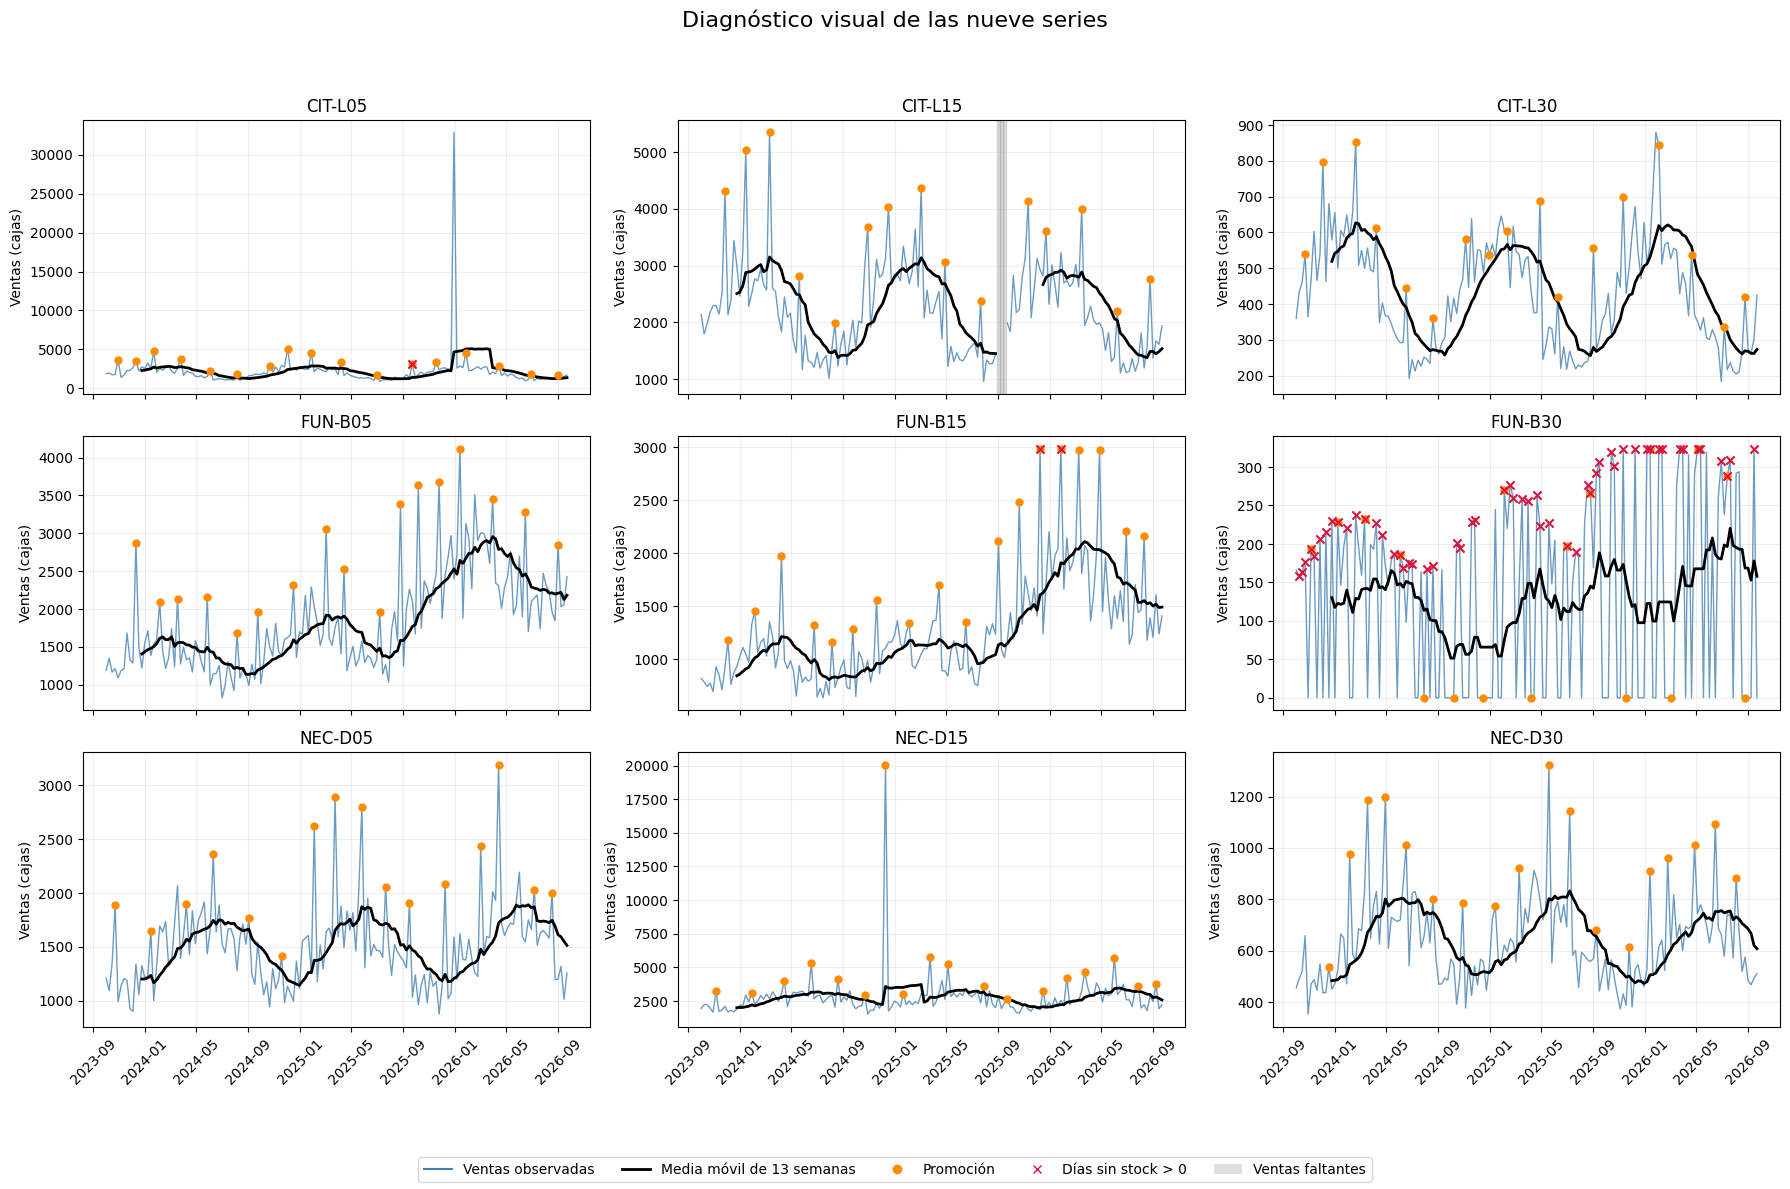

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

productos = sorted(demanda["sku"].unique())

fig, ejes = plt.subplots(
    3, 3, figsize=(18, 12), sharex=True
)

for eje, sku in zip(ejes.flat, productos):
    serie = demanda.loc[demanda["sku"] == sku].sort_values(
        "fecha_lunes"
    ).copy()

    # Ventana que usa la semana actual y las 12 anteriores.
    # Exigimos las 13 ventas para no suavizar a través de faltantes.
    media_movil = serie["ventas_cajas"].rolling(
        window=13, min_periods=13
    ).mean()

    eje.plot(
        serie["fecha_lunes"], serie["ventas_cajas"],
        color="steelblue", linewidth=1, alpha=0.8
    )

    eje.plot(
        serie["fecha_lunes"], media_movil,
        color="black", linewidth=2
    )

    promociones = serie["promocion"].eq(1)
    eje.scatter(
        serie.loc[promociones, "fecha_lunes"],
        serie.loc[promociones, "ventas_cajas"],
        color="darkorange", s=25, zorder=3
    )

    sin_stock = serie["dias_sin_stock"].gt(0)
    eje.scatter(
        serie.loc[sin_stock, "fecha_lunes"],
        serie.loc[sin_stock, "ventas_cajas"],
        color="crimson", marker="x", s=35, zorder=4
    )

    fechas_faltantes = serie.loc[
        serie["ventas_faltantes_original"], "fecha_lunes"
    ]

    for fecha in fechas_faltantes:
        eje.axvspan(
            fecha - pd.Timedelta(days=3),
            fecha + pd.Timedelta(days=4),
            color="gray", alpha=0.25
        )

    eje.set_title(sku)
    eje.set_ylabel("Ventas (cajas)")
    eje.grid(alpha=0.2)
    eje.tick_params(axis="x", rotation=45)

leyenda = [
    Line2D([0], [0], color="steelblue", label="Ventas observadas"),
    Line2D([0], [0], color="black", linewidth=2,
           label="Media móvil de 13 semanas"),
    Line2D([0], [0], marker="o", color="darkorange",
           linestyle="None", label="Promoción"),
    Line2D([0], [0], marker="x", color="crimson",
           linestyle="None", label="Días sin stock > 0"),
    Patch(facecolor="gray", alpha=0.25, label="Ventas faltantes")
]

fig.suptitle("Diagnóstico visual de las nueve series", fontsize=16)
fig.legend(handles=leyenda, loc="lower center", ncol=5)
fig.tight_layout(rect=[0, 0.07, 1, 0.95])

plt.show()

In [8]:
from google.colab import files

fig.savefig(
    "/content/diagnostico_nueve_series.png",
    dpi=200,
    bbox_inches="tight"
)

files.download("/content/diagnostico_nueve_series.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 1.4. Revisión de picos candidatos a valores atípicos

La inspección visual mostró picos aislados de gran magnitud en CIT-L05
y NEC-D15. Se localiza la venta máxima de cada serie y se compara con
las semanas cercanas, considerando promociones, precios y días sin stock.

La magnitud del pico constituye una señal para investigar; no demuestra
por sí sola un error de registro.

In [9]:
columnas = [
    "sku", "semana", "fecha_lunes", "ventas_cajas",
    "dias_sin_stock", "promocion",
    "precio_lista_clp", "precio_efectivo_clp"
]

resumen_picos = []

for sku in ["CIT-L05", "NEC-D15"]:
    serie = demanda.loc[demanda["sku"] == sku].sort_values(
        "semana"
    )

    pico = serie.loc[serie["ventas_cajas"].idxmax()]

    contexto = serie.loc[
        serie["semana"].between(
            pico["semana"] - 4,
            pico["semana"] + 4
        )
    ]

    # Referencia exploratoria: mediana de las semanas cercanas,
    # excluyendo el propio pico y los valores faltantes.
    vecinos = contexto.loc[
        contexto["semana"] != pico["semana"], "ventas_cajas"
    ].dropna()

    mediana_local = vecinos.median()

    razon = (
        pico["ventas_cajas"] / mediana_local
        if pd.notna(mediana_local) and mediana_local > 0
        else float("nan")
    )

    resumen_picos.append({
        "sku": sku,
        "semana_pico": pico["semana"],
        "fecha": pico["fecha_lunes"],
        "ventas_pico": pico["ventas_cajas"],
        "mediana_semanas_cercanas": mediana_local,
        "veces_la_mediana": razon,
        "promocion": pico["promocion"],
        "dias_sin_stock": pico["dias_sin_stock"]
    })

    print(f"\nCONTEXTO DEL PICO DE {sku}")
    display(contexto[columnas])

print("\nRESUMEN DE LOS PICOS")
display(pd.DataFrame(resumen_picos).round(2))


CONTEXTO DEL PICO DE CIT-L05


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
581,CIT-L05,114,2025-12-01,2579.0,0.0,0,5320,5320
582,CIT-L05,115,2025-12-08,2609.0,0.0,0,5320,5320
583,CIT-L05,116,2025-12-15,2435.0,0.0,0,5320,5320
584,CIT-L05,117,2025-12-22,2555.0,0.0,0,5320,5320
585,CIT-L05,118,2025-12-29,32916.0,0.0,0,5320,5320
586,CIT-L05,119,2026-01-05,2584.0,0.0,0,5320,5320
587,CIT-L05,120,2026-01-12,2866.0,0.0,0,5320,5320
588,CIT-L05,121,2026-01-19,2661.0,0.0,0,5320,5320
589,CIT-L05,122,2026-01-26,4470.0,0.0,1,5320,4392



CONTEXTO DEL PICO DE NEC-D15


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
214,NEC-D15,59,2024-11-11,1807.0,0.0,0,9930,9930
215,NEC-D15,60,2024-11-18,2370.0,0.0,0,9930,9930
216,NEC-D15,61,2024-11-25,1966.0,0.0,0,9930,9930
217,NEC-D15,62,2024-12-02,2368.0,0.0,0,9930,9930
218,NEC-D15,63,2024-12-09,20052.0,0.0,1,9930,8170
219,NEC-D15,64,2024-12-16,1752.0,0.0,0,9930,9930
220,NEC-D15,65,2024-12-23,2046.0,0.0,0,9930,9930
221,NEC-D15,66,2024-12-30,2485.0,0.0,0,9930,9930
222,NEC-D15,67,2025-01-06,2361.0,0.0,0,9930,9930



RESUMEN DE LOS PICOS


,sku,semana_pico,fecha,ventas_pico,mediana_semanas_cercanas,veces_la_mediana,promocion,dias_sin_stock
0,CIT-L05,118,2025-12-29,32916.0,2596.5,12.68,0,0.0
1,NEC-D15,63,2024-12-09,20052.0,2203.5,9.10,1,0.0


In [10]:
for sku in ["CIT-L05", "NEC-D15"]:
    serie = demanda.loc[demanda["sku"] == sku].copy()

    print(f"\n{sku}: LAS 10 MAYORES VENTAS")
    display(
        serie.nlargest(10, "ventas_cajas")[columnas]
    )

    print(f"{sku}: RESUMEN SEGÚN PROMOCIÓN")

    resumen_promociones = serie.groupby("promocion").agg(
        semanas_con_ventas=("ventas_cajas", "count"),
        mediana_ventas=("ventas_cajas", "median"),
        maxima_venta=("ventas_cajas", "max")
    )

    display(resumen_promociones.round(2))

    print(f"{sku}: MISMA ÉPOCA EN OTROS AÑOS")

    semana_pico = serie.loc[
        serie["ventas_cajas"].idxmax(), "semana"
    ]

    comparables = serie.loc[
        serie["semana"].between(semana_pico - 52 - 2,
                                semana_pico - 52 + 2)
        | serie["semana"].between(semana_pico + 52 - 2,
                                  semana_pico + 52 + 2)
    ]

    display(comparables[columnas].sort_values("semana"))


CIT-L05: LAS 10 MAYORES VENTAS


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
585,CIT-L05,118,2025-12-29,32916.0,0.0,0,5320,5320
529,CIT-L05,62,2024-12-02,5097.0,0.0,1,5320,4006
484,CIT-L05,17,2024-01-22,4738.0,0.0,1,5320,4263
537,CIT-L05,70,2025-01-27,4533.0,0.0,1,5320,4254
589,CIT-L05,122,2026-01-26,4470.0,0.0,1,5320,4392
493,CIT-L05,26,2024-03-25,3809.0,0.0,1,5320,4010
472,CIT-L05,5,2023-10-30,3572.0,0.0,1,5320,3877
478,CIT-L05,11,2023-12-11,3443.0,0.0,1,5320,4115
547,CIT-L05,80,2025-04-07,3403.0,0.0,1,5320,4130
579,CIT-L05,112,2025-11-17,3321.0,0.0,1,5320,4046


CIT-L05: RESUMEN SEGÚN PROMOCIÓN


,semanas_con_ventas,mediana_ventas,maxima_venta
promocion,,,
0,139,1761.0,32916.0
1,17,3321.0,5097.0


CIT-L05: MISMA ÉPOCA EN OTROS AÑOS


...

,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
218,NEC-D15,63,2024-12-09,20052.0,0.0,1,9930,8170
233,NEC-D15,78,2025-03-24,5750.0,0.0,1,9930,7936
295,NEC-D15,140,2026-06-01,5693.0,0.0,1,9930,7859
193,NEC-D15,38,2024-06-17,5295.0,0.0,1,9930,7047
239,NEC-D15,84,2025-05-05,5233.0,0.0,1,9930,8277
285,NEC-D15,130,2026-03-23,4677.0,0.0,1,9930,8127
279,NEC-D15,124,2026-02-09,4218.0,0.0,1,9930,7675
202,NEC-D15,47,2024-08-19,4110.0,0.0,1,9930,7173
237,NEC-D15,82,2025-04-21,4032.0,0.0,0,9930,9930
184,NEC-D15,29,2024-04-15,4016.0,0.0,1,9930,7646


NEC-D15: RESUMEN SEGÚN PROMOCIÓN


,semanas_con_ventas,mediana_ventas,maxima_venta
promocion,,,
0,138,2437.5,4032.0
1,18,3876.0,20052.0


NEC-D15: MISMA ÉPOCA EN OTROS AÑOS


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
164,NEC-D15,9,2023-11-27,2109.0,0.0,0,9930,9930
165,NEC-D15,10,2023-12-04,1685.0,0.0,0,9930,9930
166,NEC-D15,11,2023-12-11,1804.0,0.0,0,9930,9930
167,NEC-D15,12,2023-12-18,1693.0,0.0,0,9930,9930
168,NEC-D15,13,2023-12-25,1931.0,0.0,0,9930,9930
268,NEC-D15,113,2025-11-24,2111.0,0.0,0,9930,9930
269,NEC-D15,114,2025-12-01,1960.0,0.0,0,9930,9930
270,NEC-D15,115,2025-12-08,1844.0,0.0,0,9930,9930
271,NEC-D15,116,2025-12-15,3259.0,0.0,1,9930,8431
272,NEC-D15,117,2025-12-22,2031.0,0.0,0,9930,9930


### Resultado de la revisión de los dos picos

Detección: inspección visual, comparación con la mediana de las ocho
semanas cercanas, revisión de las mayores ventas y contraste con
promociones y períodos equivalentes de otros años.

CIT-L05: en la semana 118 se registran 32.916 cajas, equivalentes a
12,68 veces la mediana local. No hay promoción, cambio de precio
respecto de las semanas cercanas ni días sin stock registrados.
El pico supera ampliamente las restantes ventas y los valores
observados en la misma época del año anterior.

NEC-D15: en la semana 63 se registran 20.052 cajas, equivalentes a
9,10 veces la mediana local. Hay promoción, pero la venta también
supera ampliamente las otras semanas promocionales.

Interpretación: ambos registros son candidatos a valores atípicos.
Podrían corresponder a errores de registro o eventos comerciales
extraordinarios; su causa no puede confirmarse con los datos disponibles.

Tratamiento adoptado en esta etapa: conservar las ventas originales
y marcar ambos registros para seguimiento. No se eliminan, imputan
ni convierten de unidades sin evidencia adicional. Antes de modelar
se evaluará la sensibilidad de los resultados a su tratamiento.

In [11]:
demanda["pico_candidato_revision"] = (
    ((demanda["sku"] == "CIT-L05") & (demanda["semana"] == 118))
    | ((demanda["sku"] == "NEC-D15") & (demanda["semana"] == 63))
)

display(
    demanda.loc[
        demanda["pico_candidato_revision"],
        columnas + ["pico_candidato_revision"]
    ]
)

,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp,pico_candidato_revision
218,NEC-D15,63,2024-12-09,20052.0,0.0,1,9930,8170,True
585,CIT-L05,118,2025-12-29,32916.0,0.0,0,5320,5320,True


### 1.5. Detección exploratoria de valores inusuales en las nueve series

Cada venta se compara con la mediana de las 13 semanas anteriores.
La dispersión se mide mediante la desviación absoluta mediana (MAD).

Se marca como candidato un registro cuya distancia respecto de la
mediana supere 4,5 veces la MAD escalada por 1,4826. Este umbral es
un criterio exploratorio, no una prueba de error.

Se requieren al menos ocho observaciones válidas en la ventana.
Si la MAD es cero, no se calcula el indicador. Las promociones,
la estacionalidad, los cambios de nivel y los quiebres de stock
pueden generar alertas que requieren interpretación.

In [12]:
import numpy as np

def calcular_mad(valores):
    valores = np.asarray(valores)
    valores = valores[np.isfinite(valores)]

    if len(valores) == 0:
        return np.nan

    mediana = np.median(valores)
    return np.median(np.abs(valores - mediana))

resultados = []

for sku, grupo in demanda.groupby("sku"):
    grupo = grupo.sort_values("fecha_lunes").copy()

    # shift(1) excluye la venta actual de su propia referencia.
    anteriores = grupo["ventas_cajas"].shift(1)
    ventana = anteriores.rolling(window=13, min_periods=8)

    grupo["mediana_previa"] = ventana.median()
    grupo["mad_previa"] = ventana.apply(calcular_mad, raw=True)

    escala = (1.4826 * grupo["mad_previa"]).replace(0, np.nan)

    grupo["puntaje_robusto"] = (
        grupo["ventas_cajas"] - grupo["mediana_previa"]
    ) / escala

    grupo["evaluable_filtro"] = grupo["puntaje_robusto"].notna()
    grupo["alerta_filtro"] = grupo["puntaje_robusto"].abs().gt(4.5)

    resultados.append(grupo)

revision_atipicos = pd.concat(resultados, ignore_index=True)

print("RESUMEN POR PRODUCTO")
display(
    revision_atipicos.groupby("sku").agg(
        registros=("semana", "size"),
        registros_evaluables=("evaluable_filtro", "sum"),
        alertas=("alerta_filtro", "sum")
    )
)

print("REGISTROS MARCADOS PARA REVISIÓN")
display(
    revision_atipicos.loc[
        revision_atipicos["alerta_filtro"],
        columnas + [
            "mediana_previa", "mad_previa", "puntaje_robusto"
        ]
    ].sort_values(["sku", "semana"]).round(2)
)

RESUMEN POR PRODUCTO


,registros,registros_evaluables,alertas
sku,,,
CIT-L05,156,148,11
CIT-L15,156,145,9
CIT-L30,156,148,2
FUN-B05,156,148,8
FUN-B15,156,148,3
FUN-B30,156,100,11
NEC-D05,156,148,7
NEC-D15,156,148,8
NEC-D30,156,148,6


REGISTROS MARCADOS PARA REVISIÓN


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp,mediana_previa,mad_previa,puntaje_robusto
16,CIT-L05,17,2024-01-22,4738.0,0.0,1,5320,4263,2507.0,280.0,5.37
55,CIT-L05,56,2024-10-21,2890.0,0.0,1,5320,3987,1618.0,190.0,4.52
61,CIT-L05,62,2024-12-02,5097.0,0.0,1,5320,4006,1981.0,225.0,9.34
69,CIT-L05,70,2025-01-27,4533.0,0.0,1,5320,4254,2526.0,203.0,6.67
78,CIT-L05,79,2025-03-31,1746.0,0.0,0,5320,5320,2451.0,99.0,-4.80
...,...,...,...,...,...,...,...,...,...,...,...
1323,NEC-D30,76,2025-03-10,923.0,0.0,1,13240,9715,567.0,28.0,8.58
1367,NEC-D30,120,2026-01-12,911.0,0.0,1,13240,10279,485.0,54.0,5.32
1373,NEC-D30,126,2026-02-23,961.0,0.0,1,13240,10656,526.0,41.0,7.16
1382,NEC-D30,135,2026-04-27,1013.0,0.0,1,13240,9849,649.0,48.0,5.11


In [13]:
alertas = revision_atipicos.loc[
    revision_atipicos["alerta_filtro"]
].copy()

alertas["direccion"] = np.where(
    alertas["puntaje_robusto"] > 0, "Alta", "Baja"
)

alertas["contexto"] = np.select(
    [
        alertas["dias_sin_stock"].isna(),
        alertas["promocion"].eq(1)
        & alertas["dias_sin_stock"].gt(0),
        alertas["dias_sin_stock"].gt(0),
        alertas["promocion"].eq(1)
    ],
    [
        "Stock desconocido",
        "Promoción y días sin stock",
        "Días sin stock",
        "Promoción"
    ],
    default="Sin promoción ni días sin stock"
)

print("RESUMEN DE ALERTAS POR CONTEXTO")
display(
    alertas.groupby(["contexto", "direccion"])
    .size()
    .rename("cantidad")
    .reset_index()
)

print("ALERTAS SIN PROMOCIÓN NI DÍAS SIN STOCK")
seleccion = alertas.loc[
    alertas["contexto"] == "Sin promoción ni días sin stock"
].sort_values(["sku", "semana"])

with pd.option_context("display.max_rows", None):
    display(
        seleccion[
            columnas + ["mediana_previa", "puntaje_robusto", "direccion"]
        ].round(2)
    )

print("RESULTADO DEL FILTRO PARA LOS DOS PICOS YA INVESTIGADOS")
display(
    revision_atipicos.loc[
        revision_atipicos["pico_candidato_revision"],
        ["sku", "semana", "puntaje_robusto", "alerta_filtro"]
    ].round(2)
)

RESUMEN DE ALERTAS POR CONTEXTO


,contexto,direccion,cantidad
0,Promoción,Alta,44
1,Promoción,Baja,1
2,Promoción y días sin stock,Alta,2
3,Sin promoción ni días sin stock,Alta,5
4,Sin promoción ni días sin stock,Baja,13


ALERTAS SIN PROMOCIÓN NI DÍAS SIN STOCK


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp,mediana_previa,puntaje_robusto,direccion
78,CIT-L05,79,2025-03-31,1746.0,0.0,0,5320,5320,2451.0,-4.80,Baja
117,CIT-L05,118,2025-12-29,32916.0,0.0,0,5320,5320,2126.0,55.68,Alta
129,CIT-L05,130,2026-03-23,1760.0,0.0,0,5320,5320,2661.0,-5.06,Baja
167,CIT-L15,12,2023-12-18,3442.0,0.0,0,7980,7980,2178.0,7.10,Alta
261,CIT-L15,106,2025-10-06,2829.0,0.0,0,7980,7980,1407.5,5.06,Alta
363,CIT-L30,52,2024-09-23,423.0,0.0,0,10640,10640,246.0,6.28,Alta
565,FUN-B05,98,2025-08-11,1965.0,0.0,0,9920,9920,1332.0,4.85,Alta
789,FUN-B30,10,2023-12-04,0.0,0.0,0,19840,19840,166.0,-6.22,Baja
814,FUN-B30,35,2024-05-27,0.0,0.0,0,19840,19840,187.0,-5.05,Baja
820,FUN-B30,41,2024-07-08,0.0,0.0,0,19840,19840,174.0,-9.03,Baja


RESULTADO DEL FILTRO PARA LOS DOS PICOS YA INVESTIGADOS


,sku,semana,puntaje_robusto,alerta_filtro
117,CIT-L05,118,55.68,True
1154,NEC-D15,63,53.45,True


### 1.6. Diagnóstico de ventas cero y disponibilidad de stock

Se cuenta la frecuencia de ventas cero por SKU y se distingue si
coinciden con días sin stock, disponibilidad completa registrada
o información de stock faltante.

Los ceros no se reemplazan automáticamente. Su recurrencia puede
ser compatible con intermitencia, mientras que los días sin stock
pueden limitar las ventas observadas. Esta revisión no reconstruye
la demanda.

In [14]:
resumen_ceros = []

for sku, grupo in demanda.groupby("sku"):
    ventas = grupo["ventas_cajas"]
    stock = grupo["dias_sin_stock"]

    ceros = ventas.eq(0)
    observadas = ventas.notna()

    resumen_ceros.append({
        "sku": sku,
        "semanas_con_ventas_observadas": observadas.sum(),
        "semanas_ventas_cero": ceros.sum(),
        "porcentaje_ceros":
            100 * ceros.sum() / observadas.sum()
            if observadas.sum() > 0 else np.nan,
        "ceros_sin_quiebre_registrado":
            (ceros & stock.eq(0)).sum(),
        "ceros_con_dias_sin_stock":
            (ceros & stock.gt(0)).sum(),
        "ceros_con_stock_desconocido":
            (ceros & stock.isna()).sum(),
        "semanas_con_dias_sin_stock":
            stock.gt(0).sum(),
        "semanas_stock_desconocido":
            stock.isna().sum()
    })

display(
    pd.DataFrame(resumen_ceros).set_index("sku").round(2)
)

,semanas_con_ventas_observadas,semanas_ventas_cero,porcentaje_ceros,ceros_sin_quiebre_registrado,ceros_con_dias_sin_stock,ceros_con_stock_desconocido,semanas_con_dias_sin_stock,semanas_stock_desconocido
sku,,,,,,,,
CIT-L05,156,0,0.00,0,0,0,1,0
CIT-L15,153,0,0.00,0,0,0,0,3
CIT-L30,156,0,0.00,0,0,0,0,0
FUN-B05,156,0,0.00,0,0,0,0,0
FUN-B15,156,0,0.00,0,0,0,2,0
FUN-B30,156,69,44.23,69,0,0,55,0
NEC-D05,156,0,0.00,0,0,0,0,0
NEC-D15,156,0,0.00,0,0,0,0,0
NEC-D30,156,0,0.00,0,0,0,0,0


In [15]:
resumen_intermitencia = []

for sku, grupo in demanda.groupby("sku"):
    ventas = grupo["ventas_cajas"].dropna()
    positivas = ventas[ventas > 0]

    adi = (
        len(ventas) / len(positivas)
        if len(positivas) > 0 else np.nan
    )

    cv2 = (
        (positivas.std(ddof=1) / positivas.mean()) ** 2
        if len(positivas) >= 2 else np.nan
    )

    resumen_intermitencia.append({
        "sku": sku,
        "semanas_observadas": len(ventas),
        "semanas_ventas_positivas": len(positivas),
        "ADI": adi,
        "CV2_ventas_positivas": cv2
    })

display(
    pd.DataFrame(resumen_intermitencia).set_index("sku").round(3)
)

,semanas_observadas,semanas_ventas_positivas,ADI,CV2_ventas_positivas
sku,,,,
CIT-L05,156,156,1.000,1.387
CIT-L15,153,153,1.000,0.135
CIT-L30,156,156,1.000,0.126
FUN-B05,156,156,1.000,0.129
FUN-B15,156,156,1.000,0.148
FUN-B30,156,87,1.793,0.066
NEC-D05,156,156,1.000,0.065
NEC-D15,156,156,1.000,0.324
NEC-D30,156,156,1.000,0.074


### Resultado del diagnóstico de intermitencia

FUN-B30 presenta 69 semanas con ventas cero de un total de 156
(44,23 %), con ADI = 1,793 y CV² de las ventas positivas = 0,066.
Los ceros no coinciden con días sin stock registrados, por lo que
el patrón es compatible con intermitencia de ventas.

Tratamiento: se conservan los ceros como observaciones válidas.
No se sustituyen por promedios ni se consideran valores faltantes.
Las 55 semanas con días sin stock se analizarán por separado en
el punto 2. La variabilidad de las ventas positivas puede estar
limitada por esas restricciones de disponibilidad.

Los demás SKU presentan ventas positivas en todas las semanas
observadas. Los tres faltantes de CIT-L15 no se cuentan como ceros.

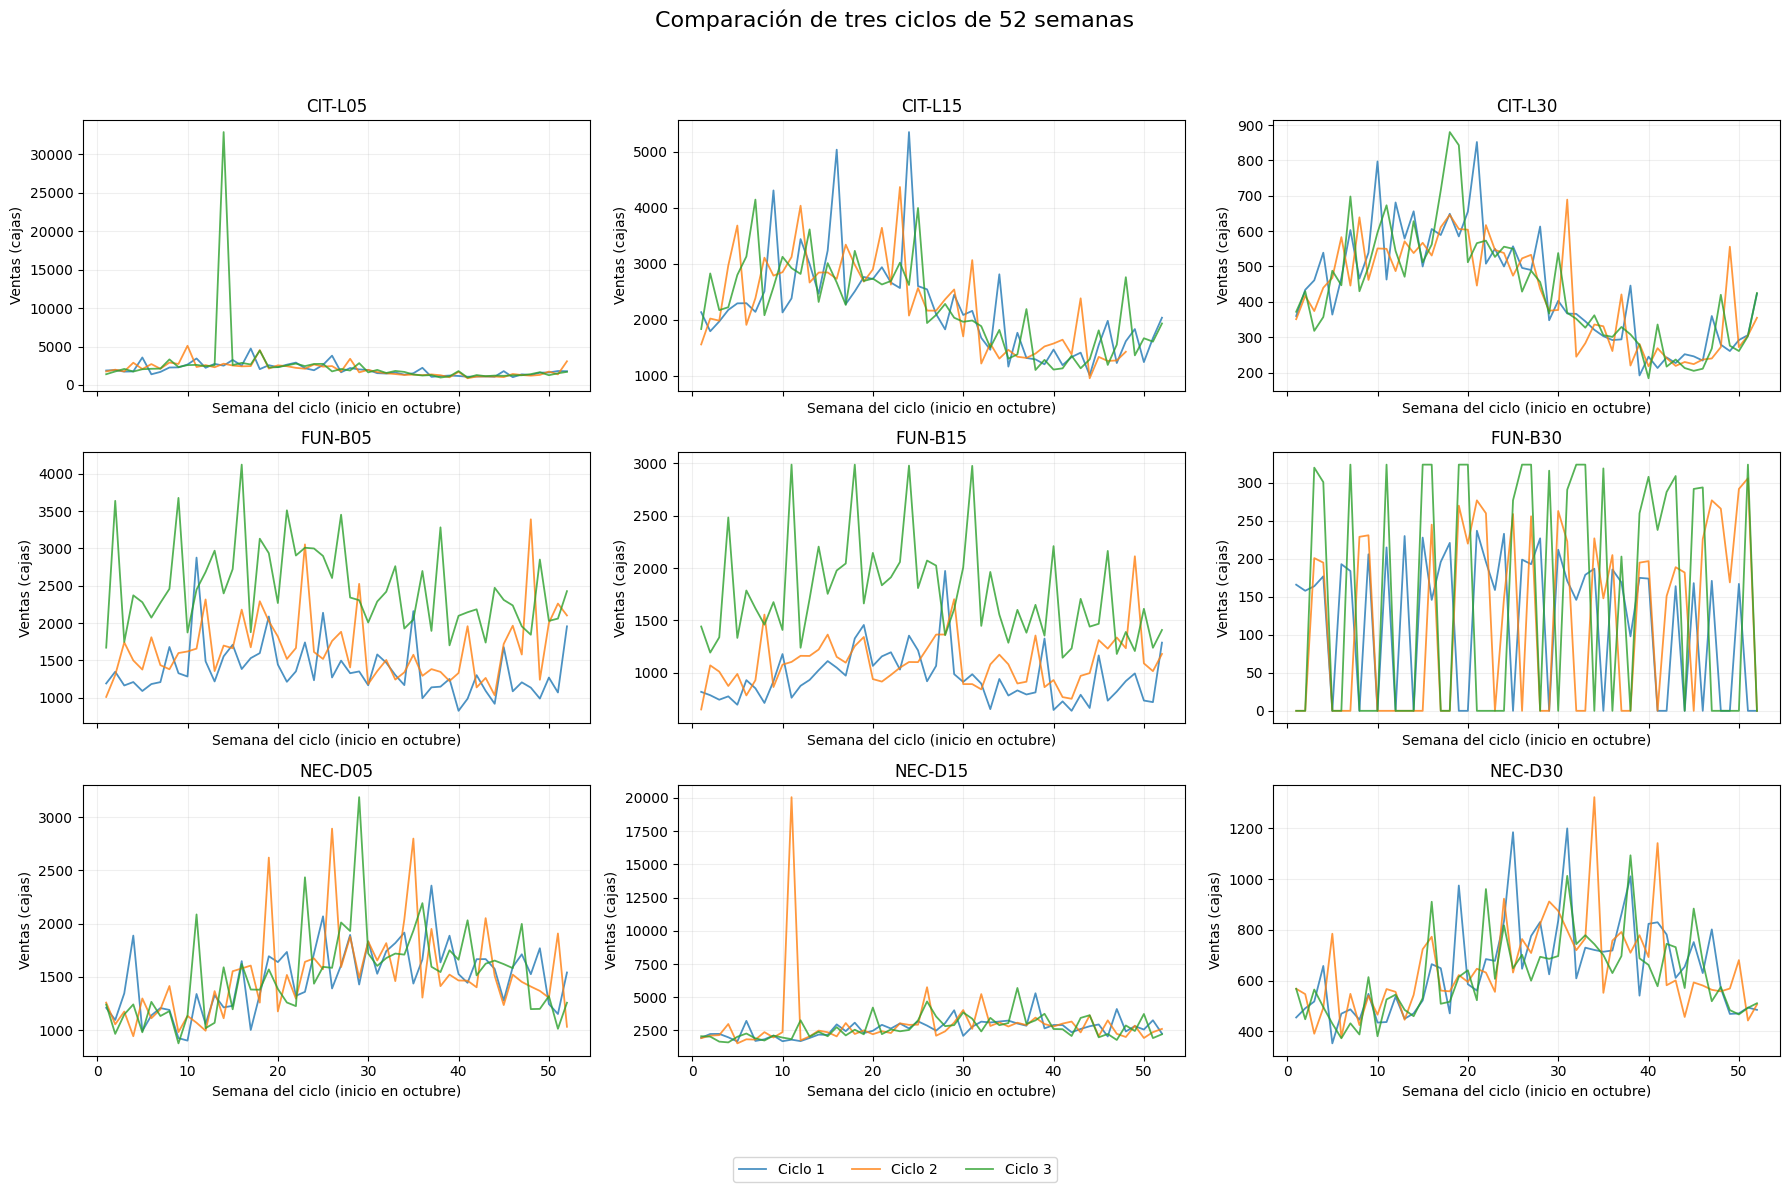

In [16]:
fig_estacional, ejes = plt.subplots(
    3, 3, figsize=(18, 12), sharex=True
)

for eje, sku in zip(ejes.flat, sorted(demanda["sku"].unique())):
    serie = demanda.loc[demanda["sku"] == sku].copy()

    # Tres bloques consecutivos de 52 semanas.
    serie["ciclo"] = ((serie["semana"] - 1) // 52) + 1
    serie["semana_del_ciclo"] = ((serie["semana"] - 1) % 52) + 1

    for ciclo, grupo in serie.groupby("ciclo"):
        grupo = grupo.sort_values("semana_del_ciclo")

        eje.plot(
            grupo["semana_del_ciclo"],
            grupo["ventas_cajas"],
            linewidth=1.3,
            alpha=0.8,
            label=f"Ciclo {int(ciclo)}"
        )

    eje.set_title(sku)
    eje.set_xlabel("Semana del ciclo (inicio en octubre)")
    eje.set_ylabel("Ventas (cajas)")
    eje.grid(alpha=0.2)

handles, labels = ejes.flat[0].get_legend_handles_labels()
fig_estacional.legend(
    handles, labels, loc="lower center", ncol=3
)

fig_estacional.suptitle(
    "Comparación de tres ciclos de 52 semanas", fontsize=16
)
fig_estacional.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

In [17]:
resumen_estacional = []

for sku, grupo in demanda.groupby("sku"):
    grupo = grupo.copy()

    grupo["ciclo"] = ((grupo["semana"] - 1) // 52) + 1
    grupo["semana_del_ciclo"] = ((grupo["semana"] - 1) % 52) + 1

    tabla = grupo.pivot(
        index="semana_del_ciclo",
        columns="ciclo",
        values="ventas_cajas"
    )

    for ciclo_a, ciclo_b in [(1, 2), (2, 3), (1, 3)]:
        pares = tabla[[ciclo_a, ciclo_b]].dropna()

        correlacion = (
            pares[ciclo_a].corr(pares[ciclo_b], method="spearman")
            if len(pares) >= 3
            and pares[ciclo_a].nunique() > 1
            and pares[ciclo_b].nunique() > 1
            else np.nan
        )

        resumen_estacional.append({
            "sku": sku,
            "comparacion": f"Ciclo {ciclo_a} vs {ciclo_b}",
            "semanas_comparables": len(pares),
            "correlacion_spearman": correlacion
        })

resultado_estacional = pd.DataFrame(resumen_estacional)

display(
    resultado_estacional.pivot(
        index="sku",
        columns="comparacion",
        values="correlacion_spearman"
    ).round(3)
)

print("NÚMERO DE SEMANAS COMPARABLES")
display(
    resultado_estacional.pivot(
        index="sku",
        columns="comparacion",
        values="semanas_comparables"
    )
)

comparacion,Ciclo 1 vs 2,Ciclo 1 vs 3,Ciclo 2 vs 3
sku,,,
CIT-L05,0.687,0.736,0.777
CIT-L15,0.681,0.699,0.655
CIT-L30,0.718,0.860,0.781
FUN-B05,0.355,0.361,0.132
FUN-B15,0.321,0.252,0.034
FUN-B30,-0.047,-0.072,0.045
NEC-D05,0.483,0.551,0.485
NEC-D15,0.298,0.382,0.274
NEC-D30,0.562,0.743,0.635


NÚMERO DE SEMANAS COMPARABLES


comparacion,Ciclo 1 vs 2,Ciclo 1 vs 3,Ciclo 2 vs 3
sku,,,
CIT-L05,52,52,52
CIT-L15,49,52,49
CIT-L30,52,52,52
FUN-B05,52,52,52
FUN-B15,52,52,52
FUN-B30,52,52,52
NEC-D05,52,52,52
NEC-D15,52,52,52
NEC-D30,52,52,52


### 1.7. Comparación del nivel de ventas entre ciclos

Se comparan semanas separadas por 52 períodos, con igual indicador
de promoción y sin días de quiebre registrados en ambas semanas.
Se excluyen de esta comparación los dos picos previamente investigados,
sin modificar sus valores originales.

Se calcula la mediana de las razones entre ventas de ambos ciclos.
Este análisis describe cambios de nivel; no identifica por sí solo
un quiebre estructural ni demuestra su causa.

In [18]:
resumen_nivel = []

for sku, grupo in demanda.groupby("sku"):
    grupo = grupo.sort_values("semana").set_index("semana")

    for ciclo_anterior, ciclo_actual in [(1, 2), (2, 3)]:
        razones = []

        inicio = (ciclo_actual - 1) * 52 + 1
        fin = ciclo_actual * 52

        for semana in range(inicio, fin + 1):
            actual = grupo.loc[semana]
            anterior = grupo.loc[semana - 52]

            comparables = (
                pd.notna(actual["ventas_cajas"])
                and pd.notna(anterior["ventas_cajas"])
                and anterior["ventas_cajas"] > 0
                and actual["dias_sin_stock"] == 0
                and anterior["dias_sin_stock"] == 0
                and actual["promocion"] == anterior["promocion"]
                and not actual["pico_candidato_revision"]
                and not anterior["pico_candidato_revision"]
            )

            if comparables:
                razones.append(
                    actual["ventas_cajas"] / anterior["ventas_cajas"]
                )

        razon_mediana = np.median(razones) if razones else np.nan

        resumen_nivel.append({
            "sku": sku,
            "comparacion": f"Ciclo {ciclo_actual} / {ciclo_anterior}",
            "pares_utilizados": len(razones),
            "razon_mediana": razon_mediana,
            "cambio_mediano_porcentaje": 100 * (razon_mediana - 1)
        })

display(pd.DataFrame(resumen_nivel).round(3))

,sku,comparacion,pares_utilizados,razon_mediana,cambio_mediano_porcentaje
0,CIT-L05,Ciclo 2 / 1,40,0.996,-0.363
1,CIT-L05,Ciclo 3 / 2,44,1.038,3.813
2,CIT-L15,Ciclo 2 / 1,39,1.037,3.740
3,CIT-L15,Ciclo 3 / 2,39,0.975,-2.469
4,CIT-L30,Ciclo 2 / 1,40,0.989,-1.102
5,CIT-L30,Ciclo 3 / 2,41,1.033,3.346
6,FUN-B05,Ciclo 2 / 1,41,1.214,21.404
7,FUN-B05,Ciclo 3 / 2,41,1.479,47.898
8,FUN-B15,Ciclo 2 / 1,43,1.181,18.053
9,FUN-B15,Ciclo 3 / 2,40,1.541,54.079


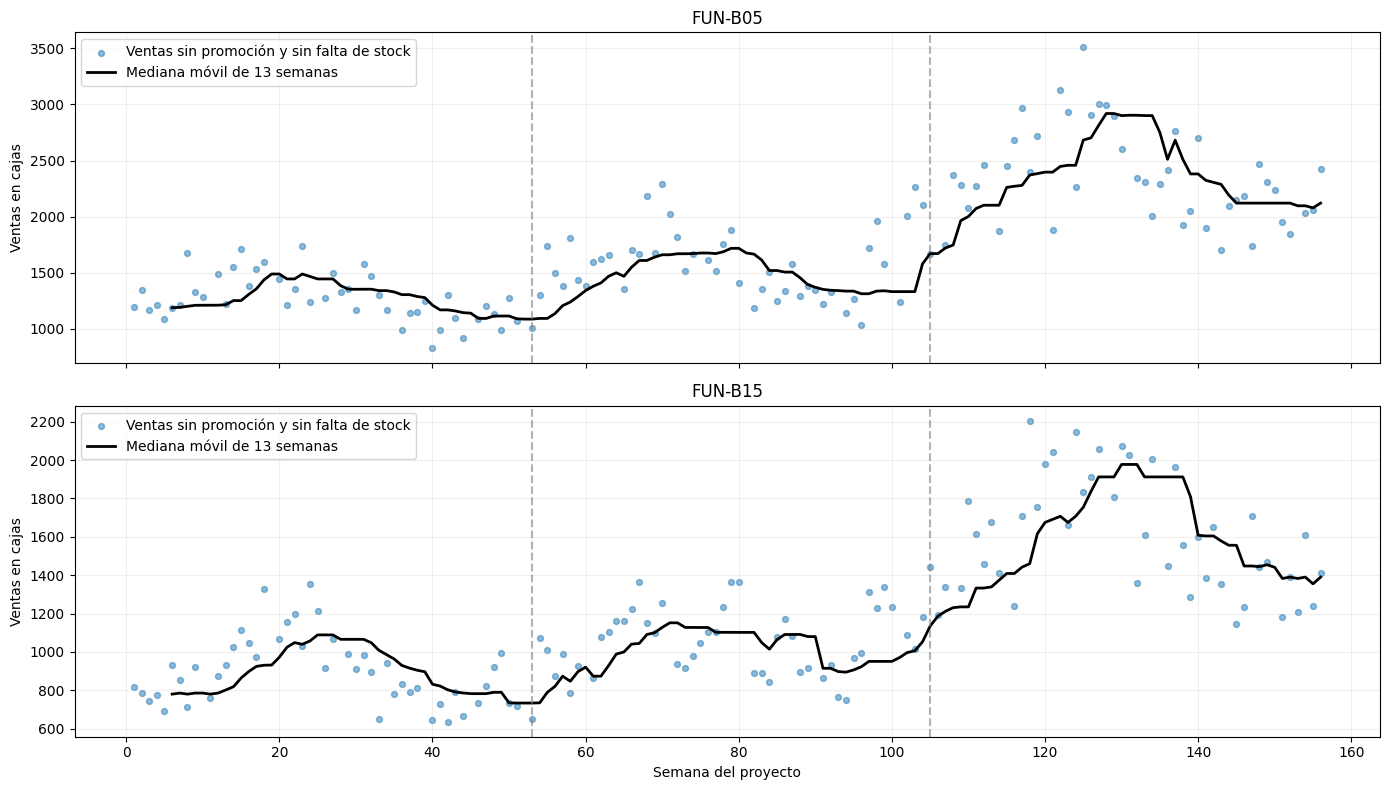

In [19]:
import matplotlib.pyplot as plt

fig_nivel, ejes = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True
)

for ax, sku in zip(ejes, ["FUN-B05", "FUN-B15"]):
    serie = (
        demanda.loc[demanda["sku"] == sku]
        .sort_values("semana")
        .copy()
    )

    # Para esta comparación utilizamos semanas sin promoción
    # y sin días registrados de falta de stock.
    ventas_comparables = serie["ventas_cajas"].where(
        (serie["promocion"] == 0)
        & (serie["dias_sin_stock"] == 0)
        & (~serie["pico_candidato_revision"])
    )

    # Mediana de las últimas 13 semanas.
    nivel_local = ventas_comparables.rolling(
        window=13, min_periods=6
    ).median()

    ax.scatter(
        serie["semana"],
        ventas_comparables,
        s=18, alpha=0.5,
        label="Ventas sin promoción y sin falta de stock"
    )

    ax.plot(
        serie["semana"],
        nivel_local,
        color="black", linewidth=2,
        label="Mediana móvil de 13 semanas"
    )

    for limite in [53, 105]:
        ax.axvline(
            limite, color="gray",
            linestyle="--", alpha=0.6
        )

    ax.set_title(sku)
    ax.set_ylabel("Ventas en cajas")
    ax.grid(alpha=0.2)
    ax.legend()

ejes[-1].set_xlabel("Semana del proyecto")
plt.tight_layout()
plt.show()

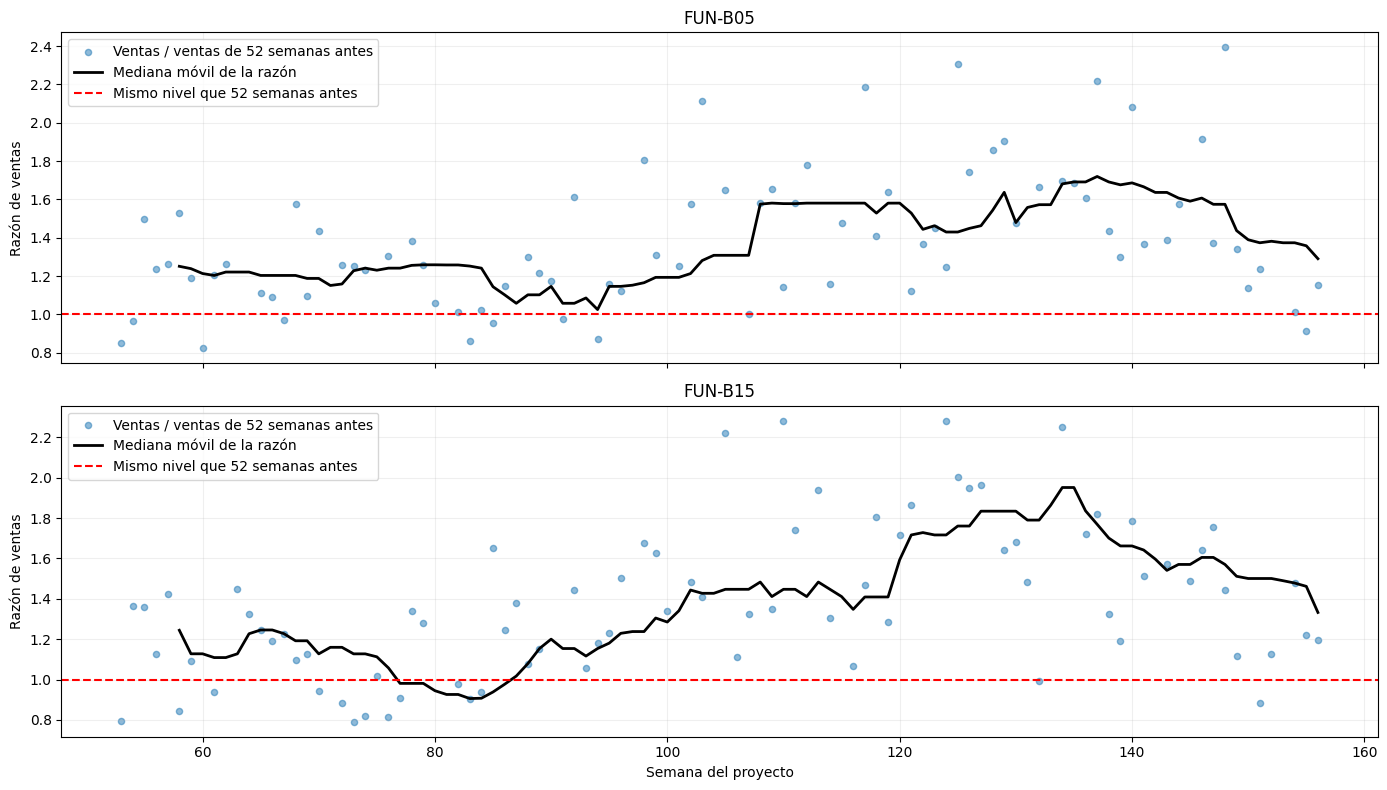

In [20]:
fig_comparacion, ejes = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True
)

for ax, sku in zip(ejes, ["FUN-B05", "FUN-B15"]):
    serie = (
        demanda.loc[demanda["sku"] == sku]
        .sort_values("semana")
        .set_index("semana")
    )

    ventas = serie["ventas_cajas"]

    semana_valida = (
        ventas.notna()
        & (serie["promocion"] == 0)
        & (serie["dias_sin_stock"] == 0)
        & (~serie["pico_candidato_revision"])
    )

    pares_validos = (
        semana_valida
        & semana_valida.shift(52, fill_value=False)
        & (ventas.shift(52) > 0)
    )

    razon = (ventas / ventas.shift(52)).where(pares_validos)

    razon_suavizada = razon.rolling(
        window=13, min_periods=6
    ).median()

    ax.scatter(
        serie.index, razon,
        s=20, alpha=0.5,
        label="Ventas / ventas de 52 semanas antes"
    )

    ax.plot(
        serie.index, razon_suavizada,
        color="black", linewidth=2,
        label="Mediana móvil de la razón"
    )

    ax.axhline(
        1, color="red", linestyle="--",
        label="Mismo nivel que 52 semanas antes"
    )

    ax.set_title(sku)
    ax.set_ylabel("Razón de ventas")
    ax.grid(alpha=0.2)
    ax.legend()

ejes[-1].set_xlabel("Semana del proyecto")
plt.tight_layout()
plt.show()

## Cambios de nivel en FUN-B05 y FUN-B15
Detección: se revisaron los gráficos de ventas, las medianas móviles de 13 semanas y las razones entre las ventas de cada semana y las de 52 semanas antes. Para estas últimas comparaciones se utilizaron pares de semanas sin promoción, sin días registrados de falta de stock y con ventas disponibles.
Hallazgo: ambas series presentan un aumento sostenido del nivel de ventas, especialmente durante el tercer ciclo. En los pares comparables, el aumento mediano respecto del segundo ciclo fue de 47,9 % para FUN-B05 y de 54,1 % para FUN-B15. Los resultados son compatibles con un cambio de nivel, aunque no permiten establecer una fecha exacta de quiebre.
Posible causa: crecimiento de la demanda, ampliación de la distribución o incorporación de clientes. Estas son hipótesis; los datos revisados no permiten confirmar una causa.
Tratamiento: se conservaron las observaciones sin reemplazarlas ni eliminarlas, porque el aumento sostenido no constituye por sí solo un error de registro. En la etapa de modelación se evaluará cómo representar este cambio y su efecto sobre los pronósticos.

In [21]:
base_promociones = demanda.loc[
    demanda["ventas_cajas"].notna()
    & (demanda["dias_sin_stock"] == 0)
    & (~demanda["pico_candidato_revision"])
].copy()

resumen_promociones = []

for sku, grupo in base_promociones.groupby("sku"):
    sin_promo = grupo.loc[grupo["promocion"] == 0]
    con_promo = grupo.loc[grupo["promocion"] == 1]

    mediana_sin = sin_promo["ventas_cajas"].median()
    mediana_con = con_promo["ventas_cajas"].median()

    razon = (
        mediana_con / mediana_sin
        if pd.notna(mediana_sin) and mediana_sin > 0
        else np.nan
    )

    precios_validos = con_promo.loc[
        (con_promo["precio_lista_clp"] > 0)
        & con_promo["precio_efectivo_clp"].notna()
    ]

    descuento = (
        100 * (
            1
            - precios_validos["precio_efectivo_clp"]
            / precios_validos["precio_lista_clp"]
        )
    ).median()

    resumen_promociones.append({
        "sku": sku,
        "semanas_sin_promo": len(sin_promo),
        "semanas_con_promo": len(con_promo),
        "mediana_sin_promo": mediana_sin,
        "mediana_con_promo": mediana_con,
        "razon_con_vs_sin": razon,
        "descuento_mediano_promo_pct": descuento
    })

tabla_promociones = pd.DataFrame(resumen_promociones)

display(tabla_promociones.round(2))

,sku,semanas_sin_promo,semanas_con_promo,mediana_sin_promo,mediana_con_promo,razon_con_vs_sin,descuento_mediano_promo_pct
0,CIT-L05,138,16,1760.5,3362.0,1.91,23.97
1,CIT-L15,138,15,2080.0,3684.0,1.77,19.41
2,CIT-L30,139,17,417.0,556.0,1.33,24.30
3,FUN-B05,139,17,1599.0,2850.0,1.78,23.18
4,FUN-B15,138,16,1099.5,1629.5,1.48,22.76
5,FUN-B30,94,7,0.0,0.0,NaN,23.63
6,NEC-D05,140,16,1432.0,2042.0,1.43,25.32
7,NEC-D15,138,17,2437.5,3736.0,1.53,22.60
8,NEC-D30,138,18,579.5,942.0,1.63,22.69


##Promociones y precios
Detección: se compararon las medianas de ventas de semanas con y sin promoción para cada SKU. Se excluyeron de esta comparación los registros con ventas faltantes, días de falta de stock y los dos picos candidatos previamente identificados. También se calculó el descuento porcentual entre el precio de lista y el precio efectivo.

Hallazgo: en ocho series, las ventas medianas durante promociones fueron mayores que en semanas sin promoción, con diferencias aproximadas entre 33 % y 91 %. Los descuentos medianos promocionales estuvieron entre 19,4 % y 25,3 %. Esta asociación no constituye una estimación causal, porque también pueden influir la estacionalidad y los cambios de nivel.
Caso FUN-B30: las medianas fueron cero en ambos grupos, por lo que no se pudo calcular la razón. La intermitencia y la exclusión de semanas con falta de stock limitan esta comparación.

Tratamiento: se conservaron las ventas promocionales y las variables de promoción y precio. Una venta elevada coincidente con una promoción no se consideró automáticamente un error; los casos extremos se revisaron por separado.

### Bitácora de anomalías y decisiones

| Caso | Cómo se detectó | Hallazgo y posible causa | Tratamiento realizado |
|---|---|---|---|
| Faltantes en CIT-L15, semanas 101, 102 y 103 | Recuento de valores nulos y revisión de las semanas cercanas. | Faltan ventas y días sin stock en tres semanas consecutivas. Posible falla de registro o extracción; causa no confirmada. | Se conservaron las filas y los valores faltantes, con indicadores que permiten identificarlos. No se reemplazaron por cero ni se supuso disponibilidad de stock. La imputación para modelar queda pendiente y deberá utilizar únicamente información disponible en cada entrenamiento. |
| Pico en CIT-L05, semana 118 | Gráfico, comparación con semanas cercanas, otras temporadas y filtro robusto de mediana y MAD. | Venta de 32.916 cajas, aproximadamente 12,68 veces la mediana de las ocho semanas vecinas. No registra promoción ni días sin stock. Posible error de registro o pedido extraordinario; causa no confirmada. | Se conservó el valor original y se marcó como pico candidato a revisión. Se excluyó únicamente de las comparaciones descriptivas de nivel y promociones. No se aplicó una corrección definitiva. |
| Pico en NEC-D15, semana 63 | Gráfico, comparación con semanas cercanas, otras promociones y filtro robusto de mediana y MAD. | Venta de 20.052 cajas, aproximadamente 9,10 veces la mediana de las ocho semanas vecinas. Coincide con una promoción, pero también supera ampliamente otras ventas promocionales. Posible evento extraordinario o error de registro; causa no confirmada. | Se conservó el valor original y se marcó como pico candidato a revisión. Se excluyó únicamente de las comparaciones descriptivas de nivel y promociones. No se aplicó una corrección definitiva. |
| Otras alertas del filtro robusto en las nueve series | Desviación respecto de la mediana de las 13 semanas anteriores, escalada mediante MAD; umbral absoluto de 4,5. | El filtro produjo 65 alertas en total, incluidos los dos picos anteriores. De ellas, 47 coinciden con promociones y 18 no registran promoción ni días sin stock. Las alertas pueden reflejar promociones, estacionalidad, cambios de nivel o intermitencia; no equivalen automáticamente a errores. | Se conservaron las observaciones y el registro de alertas con su contexto. No se reemplazaron ni eliminaron datos de forma automática. |
| Ceros e intermitencia en FUN-B30 | Recuento de ventas iguales a cero, revisión de días sin stock y cálculo de ADI y CV². | Se observaron 69 semanas con ventas cero de 156, equivalentes al 44,23 %. Todas registran cero días sin stock. El ADI observado fue aproximadamente 1,79. Patrón compatible con ventas intermitentes; la causa comercial no está confirmada. | Se conservaron los ceros como ventas observadas y se distinguieron de los datos faltantes. No se interpolaron ni se sustituyeron por ventas positivas. |
| Posible cambio de nivel en FUN-B05 y FUN-B15 | Gráficos, medianas móviles y comparación con ventas de 52 semanas antes, utilizando pares comparables. | Aumento sostenido, especialmente en el tercer ciclo. El cambio mediano entre los ciclos 2 y 3 fue de +47,9 % y +54,1 %, respectivamente. Posible crecimiento comercial; no se confirmó una causa ni una fecha exacta de quiebre. | Se conservaron las ventas, porque un aumento sostenido no constituye por sí solo un error. Se documentó el cambio para considerarlo posteriormente en la modelación. |
| Ventas elevadas durante promociones | Comparación de medianas con y sin promoción y cálculo de descuentos. | En ocho series, las medianas promocionales son mayores. La promoción es una explicación posible de parte del aumento, pero la comparación no demuestra causalidad. En FUN-B30, ambas medianas son cero y la razón no se puede calcular. | Se conservaron las ventas y las variables de promoción y precio. Las observaciones extremas se revisaron por separado. |
| Semanas con falta de stock | Identificación de registros con dias_sin_stock mayor que cero. | Se detectaron 55 semanas en FUN-B30, dos en FUN-B15 y una en CIT-L05. Las ventas de estas semanas pueden estar limitadas por falta de disponibilidad y no representar toda la demanda. | Se identificaron y conservaron los registros. Se excluyeron de algunas comparaciones descriptivas. La reconstrucción de demanda corresponde al punto 2 y todavía no se ha realizado. |

Los archivos originales permanecen sin modificaciones. Conservar una observación, marcarla o excluirla de una comparación descriptiva son decisiones distintas de reemplazar su valor para entrenar un modelo. Los tratamientos pendientes se documentan explícitamente.

### Resumen del diagnóstico de las nueve series

| Serie | Tendencia y cambios de nivel | Estacionalidad | Faltantes | Valores atípicos y promociones | Intermitencia y disponibilidad |
|---|---|---|---|---|---|
| CIT-L05 | Nivel relativamente estable entre ciclos, sin aumento sostenido importante en la comparación realizada. | Patrón anual visible y repetido, con mayores ventas en verano. | Sin faltantes. | Pico candidato en semana 118: 32.916 cajas. Ventas medianas mayores durante promociones. | Sin semanas con ventas cero. Una semana con falta de stock. |
| CIT-L15 | Cambios pequeños de nivel entre ciclos comparables. | Patrón anual visible y repetido, con mayores ventas en verano. | Ventas y días sin stock faltantes en semanas 101–103. | Alertas del filtro robusto que requieren interpretación contextual. Ventas medianas mayores durante promociones. | Sin ceros entre las ventas disponibles. Disponibilidad desconocida en las tres semanas faltantes. |
| CIT-L30 | Nivel relativamente estable entre ciclos. | Patrón anual visible y repetido, con mayores ventas en verano. | Sin faltantes. | Alertas puntuales del filtro robusto. Ventas medianas mayores durante promociones. | Sin ventas cero ni días registrados de falta de stock. |
| FUN-B05 | Aumento sostenido del nivel, especialmente en el tercer ciclo; posible cambio de nivel sin fecha exacta confirmada. | Oscilaciones dentro de los ciclos, con menor repetición que las series CIT. El cambio de nivel dificulta la comparación. | Sin faltantes. | Alertas que pueden coincidir con promociones y aumentos de nivel. Ventas medianas mayores durante promociones. | Sin ventas cero ni días registrados de falta de stock. |
| FUN-B15 | Aumento sostenido del nivel, especialmente en el tercer ciclo; posible cambio de nivel sin fecha exacta confirmada. | Oscilaciones dentro de los ciclos, con poca concordancia entre sus posiciones semanales. | Sin faltantes. | Alertas del filtro robusto. Ventas medianas mayores durante promociones. | Sin ventas cero. Dos semanas con falta de stock. |
| FUN-B30 | No se establece una tendencia clara mediante las comparaciones realizadas. | Sin patrón anual claro en los gráficos y comparaciones entre ciclos. | Sin faltantes. | Varias alertas corresponden a ceros. La razón de medianas promocionales no es calculable porque ambas medianas son cero. | Ventas intermitentes: 69 semanas con cero, equivalentes al 44,23 %. Además, 55 semanas con falta de stock. |
| NEC-D05 | Cambios pequeños de nivel entre ciclos comparables. | Patrón anual visible, con mayores ventas aproximadamente en otoño e invierno. | Sin faltantes. | Alertas puntuales del filtro robusto. Ventas medianas mayores durante promociones. | Sin ventas cero ni días registrados de falta de stock. |
| NEC-D15 | Cambios pequeños de nivel entre ciclos comparables. | Patrón anual sugerido por los gráficos, con menor concordancia entre ciclos que NEC-D05 y NEC-D30. | Sin faltantes. | Pico candidato en semana 63: 20.052 cajas, coincidente con promoción. Ventas medianas mayores durante promociones. | Sin ventas cero ni días registrados de falta de stock. |
| NEC-D30 | Cambios pequeños de nivel entre ciclos comparables. | Patrón anual visible y repetido, con mayores ventas aproximadamente en otoño e invierno. | Sin faltantes. | Alertas del filtro robusto. Ventas medianas mayores durante promociones. | Sin ventas cero ni días registrados de falta de stock. |

### Alcance y decisiones del diagnóstico

El diagnóstico se realizó sobre las ventas observadas. En las semanas con falta de stock, estas pueden ser inferiores a la demanda real.

La estacionalidad y los cambios de nivel se evaluaron mediante gráficos y comparaciones descriptivas. No se confirmó una causa comercial para los cambios ni una fecha exacta de quiebre. Una alerta estadística no se consideró automáticamente un error.

Se conservaron los datos originales, los ceros observados y las ventas promocionales. Se identificaron los faltantes, los picos candidatos y las semanas con falta de stock. La imputación de faltantes y la decisión definitiva sobre los dos picos permanecen pendientes antes de entrenar los modelos.

La reconstrucción de demanda por falta de stock se abordará en el punto 2. Cualquier transformación para evaluar pronósticos deberá utilizar únicamente la información disponible dentro de cada periodo de entrenamiento.

## 2. Tratamiento de censura por falta de stock

### 2.1. Identificación de semanas censuradas

Se identifican como potencialmente censuradas las semanas con días registrados de falta de stock. En ellas, las ventas observadas pueden ser inferiores a la demanda real.

Los registros sin información de disponibilidad se mantienen separados: no se supone que tuvieron stock ni que estuvieron censurados.

In [22]:
# Creamos una copia para trabajar el punto 2.
demanda_censura = demanda.copy()

demanda_censura["estado_stock"] = np.select(
    [
        demanda_censura["dias_sin_stock"].isna(),
        demanda_censura["dias_sin_stock"] > 0
    ],
    [
        "Disponibilidad desconocida",
        "Potencialmente censurada"
    ],
    default="Sin falta de stock registrada"
)

resumen_censura = (
    demanda_censura
    .groupby(["sku", "estado_stock"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Sin falta de stock registrada",
            "Potencialmente censurada",
            "Disponibilidad desconocida"
        ],
        fill_value=0
    )
)

display(resumen_censura)

semanas_censuradas = demanda_censura.loc[
    demanda_censura["dias_sin_stock"] > 0,
    [
        "sku",
        "semana",
        "fecha_lunes",
        "ventas_cajas",
        "dias_sin_stock",
        "promocion"
    ]
].sort_values(["sku", "semana"])

print(
    "Total de semanas potencialmente censuradas:",
    len(semanas_censuradas)
)

display(semanas_censuradas.head(15))

display(
    semanas_censuradas
    .groupby(["sku", "dias_sin_stock"])
    .size()
    .rename("numero_semanas")
    .reset_index()
)

estado_stock,Sin falta de stock registrada,Potencialmente censurada,Disponibilidad desconocida
sku,,,
CIT-L05,155,1,0
CIT-L15,153,0,3
CIT-L30,156,0,0
FUN-B05,156,0,0
FUN-B15,154,2,0
FUN-B30,101,55,0
NEC-D05,156,0,0
NEC-D15,156,0,0
NEC-D30,156,0,0


Total de semanas potencialmente censuradas: 58


,sku,semana,fecha_lunes,ventas_cajas,dias_sin_stock,promocion
571,CIT-L05,104,2025-09-22,3078.0,1.0,1
1206,FUN-B15,115,2025-12-08,2988.0,1.0,1
1213,FUN-B15,122,2026-01-26,2988.0,1.0,1
1249,FUN-B30,2,2023-10-09,158.0,2.0,0
1250,FUN-B30,3,2023-10-16,164.0,1.0,0
1251,FUN-B30,4,2023-10-23,177.0,1.0,0
1253,FUN-B30,6,2023-11-06,193.0,4.0,1
1254,FUN-B30,7,2023-11-13,184.0,1.0,0
1256,FUN-B30,9,2023-11-27,206.0,4.0,0
1258,FUN-B30,11,2023-12-11,215.0,3.0,0


,sku,dias_sin_stock,numero_semanas
0,CIT-L05,1.0,1
1,FUN-B15,1.0,2
2,FUN-B30,1.0,10
3,FUN-B30,2.0,21
4,FUN-B30,3.0,12
5,FUN-B30,4.0,9
6,FUN-B30,5.0,3


### 2.2. Reconstrucción proporcional por disponibilidad

Se calcula una estimación inicial de demanda multiplicando las ventas observadas por 7 / (7 − días sin stock).

El método supone siete días de posible venta por semana y una demanda diaria aproximadamente constante dentro de cada semana. No permite conocer con certeza las ventas perdidas ni representar diferencias entre días.

Las ventas originales se conservan. Los registros con disponibilidad desconocida permanecen sin reconstruir. Los ceros sin falta de stock registrada se mantienen como ceros.

In [23]:
def reconstruir_por_disponibilidad(datos):
    resultado = datos.copy()

    dias = resultado["dias_sin_stock"]
    ventas = resultado["ventas_cajas"]

    sin_censura = dias.eq(0) & ventas.notna()
    censura_parcial = dias.gt(0) & dias.lt(7) & ventas.notna()

    resultado["dias_disponibles"] = 7 - dias

    resultado["factor_disponibilidad"] = np.nan
    resultado.loc[sin_censura, "factor_disponibilidad"] = 1.0
    resultado.loc[
        censura_parcial, "factor_disponibilidad"
    ] = 7 / resultado.loc[censura_parcial, "dias_disponibles"]

    resultado["demanda_estimada_disponibilidad"] = np.nan

    resultado.loc[
        sin_censura, "demanda_estimada_disponibilidad"
    ] = ventas.loc[sin_censura]

    resultado.loc[
        censura_parcial, "demanda_estimada_disponibilidad"
    ] = (
        ventas.loc[censura_parcial]
        * resultado.loc[censura_parcial, "factor_disponibilidad"]
    )

    resultado["cajas_adicionales_estimadas"] = (
        resultado["demanda_estimada_disponibilidad"] - ventas
    )

    resultado["tratamiento_censura"] = np.select(
        [
            ventas.isna(),
            dias.isna(),
            dias.eq(7),
            censura_parcial,
            sin_censura
        ],
        [
            "Ventas faltantes: pendiente",
            "Disponibilidad desconocida: pendiente",
            "Sin disponibilidad: requiere otro método",
            "Ajuste proporcional por disponibilidad",
            "Ventas conservadas sin ajuste"
        ],
        default="Registro a revisar"
    )

    return resultado


demanda_censura = reconstruir_por_disponibilidad(demanda_censura)

columnas_revision = [
    "sku",
    "semana",
    "ventas_cajas",
    "dias_sin_stock",
    "dias_disponibles",
    "factor_disponibilidad",
    "demanda_estimada_disponibilidad",
    "cajas_adicionales_estimadas"
]

ajustes_censura = demanda_censura.loc[
    demanda_censura["dias_sin_stock"] > 0,
    columnas_revision
].sort_values(["sku", "semana"])

display(ajustes_censura.head(15).round(2))

resumen_ajustes = (
    ajustes_censura.groupby("sku")
    .agg(
        semanas_ajustadas=("semana", "size"),
        ventas_observadas=("ventas_cajas", "sum"),
        demanda_estimada=("demanda_estimada_disponibilidad", "sum"),
        cajas_adicionales=("cajas_adicionales_estimadas", "sum"),
        factor_maximo=("factor_disponibilidad", "max")
    )
)

display(resumen_ajustes.round(2))

,sku,semana,ventas_cajas,dias_sin_stock,dias_disponibles,factor_disponibilidad,demanda_estimada_disponibilidad,cajas_adicionales_estimadas
571,CIT-L05,104,3078.0,1.0,6.0,1.17,3591.00,513.00
1206,FUN-B15,115,2988.0,1.0,6.0,1.17,3486.00,498.00
1213,FUN-B15,122,2988.0,1.0,6.0,1.17,3486.00,498.00
1249,FUN-B30,2,158.0,2.0,5.0,1.40,221.20,63.20
1250,FUN-B30,3,164.0,1.0,6.0,1.17,191.33,27.33
1251,FUN-B30,4,177.0,1.0,6.0,1.17,206.50,29.50
1253,FUN-B30,6,193.0,4.0,3.0,2.33,450.33,257.33
1254,FUN-B30,7,184.0,1.0,6.0,1.17,214.67,30.67
1256,FUN-B30,9,206.0,4.0,3.0,2.33,480.67,274.67
1258,FUN-B30,11,215.0,3.0,4.0,1.75,376.25,161.25


,semanas_ajustadas,ventas_observadas,demanda_estimada,cajas_adicionales,factor_maximo
sku,,,,,
CIT-L05,1,3078.0,3591.0,513.0,1.17
FUN-B15,2,5976.0,6972.0,996.0,1.17
FUN-B30,55,13623.0,23491.3,9868.3,3.50


,resultado
Semanas censuradas con estimación,58
Estimaciones inferiores a ventas observadas,0
Semanas sin censura modificadas,0
Ceros sin censura modificados,0
Estimaciones infinitas,0
Registros sin estimación,3


Diez casos con mayor factor de ajuste:


,sku,semana,ventas_cajas,dias_sin_stock,dias_disponibles,factor_disponibilidad,demanda_estimada_disponibilidad,cajas_adicionales_estimadas
1367,FUN-B30,120,324.0,5.0,2.0,3.50,1134.00,810.00
1377,FUN-B30,130,324.0,5.0,2.0,3.50,1134.00,810.00
1339,FUN-B30,92,197.0,5.0,2.0,3.50,689.50,492.50
1378,FUN-B30,131,324.0,4.0,3.0,2.33,756.00,432.00
1383,FUN-B30,136,324.0,4.0,3.0,2.33,756.00,432.00
1320,FUN-B30,73,277.0,4.0,3.0,2.33,646.33,369.33
1318,FUN-B30,71,270.0,4.0,3.0,2.33,630.00,360.00
1326,FUN-B30,79,256.0,4.0,3.0,2.33,597.33,341.33
1256,FUN-B30,9,206.0,4.0,3.0,2.33,480.67,274.67
1253,FUN-B30,6,193.0,4.0,3.0,2.33,450.33,257.33


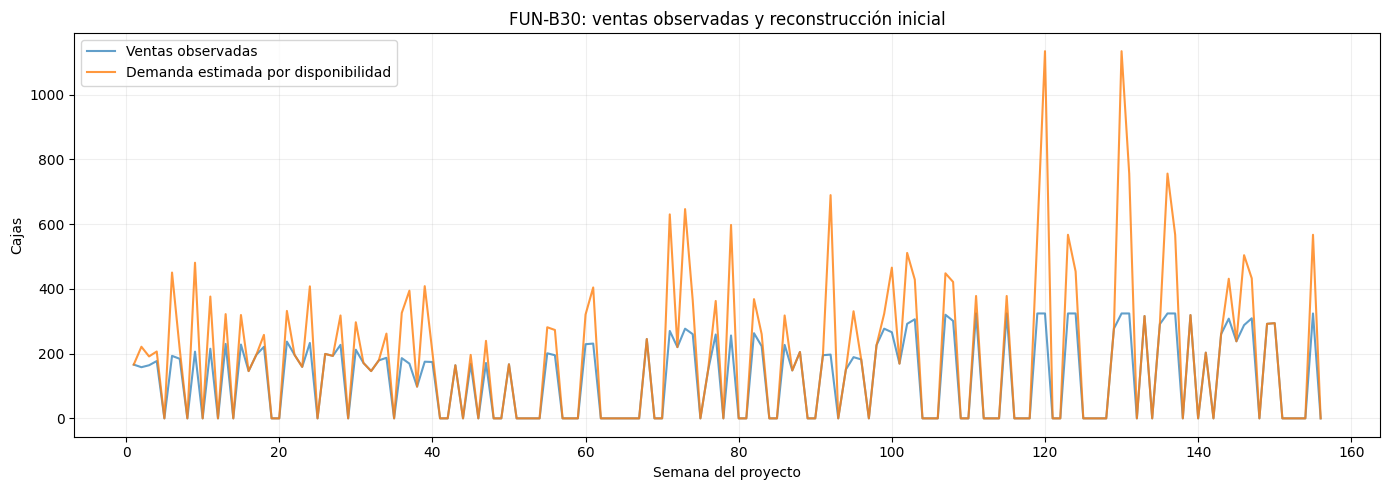

In [24]:
ventas = demanda_censura["ventas_cajas"]
estimacion = demanda_censura["demanda_estimada_disponibilidad"]
dias = demanda_censura["dias_sin_stock"]

sin_censura = dias.eq(0) & ventas.notna()
con_censura = dias.gt(0) & dias.lt(7) & ventas.notna()

ceros_sin_censura = sin_censura & ventas.eq(0)

comprobaciones = pd.Series({
    "Semanas censuradas con estimación":
        int((con_censura & estimacion.notna()).sum()),

    "Estimaciones inferiores a ventas observadas":
        int((con_censura & (estimacion < ventas)).sum()),

    "Semanas sin censura modificadas":
        int((
            sin_censura
            & ~np.isclose(estimacion, ventas, equal_nan=True)
        ).sum()),

    "Ceros sin censura modificados":
        int((
            ceros_sin_censura
            & ~estimacion.eq(0)
        ).sum()),

    "Estimaciones infinitas":
        int(np.isinf(estimacion).sum()),

    "Registros sin estimación":
        int(estimacion.isna().sum())
})

display(comprobaciones.to_frame("resultado"))

print("Diez casos con mayor factor de ajuste:")

display(
    ajustes_censura
    .sort_values(
        ["factor_disponibilidad", "cajas_adicionales_estimadas"],
        ascending=False
    )
    .head(10)
    .round(2)
)

serie = (
    demanda_censura.loc[demanda_censura["sku"] == "FUN-B30"]
    .sort_values("semana")
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    serie["semana"],
    serie["ventas_cajas"],
    label="Ventas observadas",
    alpha=0.7
)

ax.plot(
    serie["semana"],
    serie["demanda_estimada_disponibilidad"],
    label="Demanda estimada por disponibilidad",
    alpha=0.8
)

ax.set_title("FUN-B30: ventas observadas y reconstrucción inicial")
ax.set_xlabel("Semana del proyecto")
ax.set_ylabel("Cajas")
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
comparacion_sensibilidad = []

for sku, grupo in demanda_censura.groupby("sku"):
    censuradas = grupo.loc[
        grupo["dias_sin_stock"].gt(0)
        & grupo["dias_sin_stock"].lt(7)
        & grupo["ventas_cajas"].notna()
    ].copy()

    if censuradas.empty:
        continue

    ventas = censuradas["ventas_cajas"]
    factor = censuradas["factor_disponibilidad"]

    escenarios = {
        "Sin ajuste": ventas,
        "Factor limitado a 2": ventas * factor.clip(upper=2),
        "Proporcional completo": ventas * factor
    }

    for nombre, valores in escenarios.items():
        comparacion_sensibilidad.append({
            "sku": sku,
            "escenario": nombre,
            "semanas": len(censuradas),
            "total_cajas": valores.sum(),
            "cajas_adicionales": (valores - ventas).sum(),
            "maximo_semanal": valores.max()
        })

tabla_sensibilidad = pd.DataFrame(comparacion_sensibilidad)

display(tabla_sensibilidad.round(2))

,sku,escenario,semanas,total_cajas,cajas_adicionales,maximo_semanal
0,CIT-L05,Sin ajuste,1,3078.00,0.00,3078.0
1,CIT-L05,Factor limitado a 2,1,3591.00,513.00,3591.0
2,CIT-L05,Proporcional completo,1,3591.00,513.00,3591.0
3,FUN-B15,Sin ajuste,2,5976.00,0.00,2988.0
4,FUN-B15,Factor limitado a 2,2,6972.00,996.00,3486.0
5,FUN-B15,Proporcional completo,2,6972.00,996.00,3486.0
6,FUN-B30,Sin ajuste,55,13623.00,0.00,324.0
7,FUN-B30,Factor limitado a 2,55,21492.47,7869.47,648.0
8,FUN-B30,Proporcional completo,55,23491.30,9868.30,1134.0


In [26]:
def preparar_censura_entrenamiento(datos, semana_corte):
    entrenamiento = datos.loc[
        datos["semana"] <= semana_corte
    ].copy()

    resultado = reconstruir_por_disponibilidad(entrenamiento)

    ventas = resultado["ventas_cajas"]
    dias = resultado["dias_sin_stock"]

    datos_validos = (
        ventas.notna()
        & dias.ge(0)
        & dias.lt(7)
    )

    resultado["objetivo_sin_ajuste"] = ventas.where(datos_validos)

    resultado["objetivo_proporcional"] = (
        resultado["demanda_estimada_disponibilidad"]
    )

    resultado["objetivo_factor_maximo_2"] = (
        ventas
        * resultado["factor_disponibilidad"].clip(upper=2)
    )

    return resultado


# Ejemplo para comprobar el corte.
# Todavía no estamos entrenando modelos.
ejemplo_entrenamiento = preparar_censura_entrenamiento(
    demanda, semana_corte=104
)

print(
    "Última semana incluida:",
    ejemplo_entrenamiento["semana"].max()
)

print(
    "Registros posteriores al corte:",
    (ejemplo_entrenamiento["semana"] > 104).sum()
)

display(
    ejemplo_entrenamiento.loc[
        ejemplo_entrenamiento["dias_sin_stock"] > 0,
        [
            "sku",
            "semana",
            "ventas_cajas",
            "dias_sin_stock",
            "objetivo_sin_ajuste",
            "objetivo_factor_maximo_2",
            "objetivo_proporcional"
        ]
    ].head(10).round(2)
)

Última semana incluida: 104
Registros posteriores al corte: 0


,sku,semana,ventas_cajas,dias_sin_stock,objetivo_sin_ajuste,objetivo_factor_maximo_2,objetivo_proporcional
571,CIT-L05,104,3078.0,1.0,3078.0,3591.00,3591.00
1249,FUN-B30,2,158.0,2.0,158.0,221.20,221.20
1250,FUN-B30,3,164.0,1.0,164.0,191.33,191.33
1251,FUN-B30,4,177.0,1.0,177.0,206.50,206.50
1253,FUN-B30,6,193.0,4.0,193.0,386.00,450.33
1254,FUN-B30,7,184.0,1.0,184.0,214.67,214.67
1256,FUN-B30,9,206.0,4.0,206.0,412.00,480.67
1258,FUN-B30,11,215.0,3.0,215.0,376.25,376.25
1260,FUN-B30,13,230.0,2.0,230.0,322.00,322.00
1262,FUN-B30,15,228.0,2.0,228.0,319.20,319.20


### 2.3. Resultados, sensibilidad y aplicación en entrenamiento

Se identificaron 58 semanas potencialmente censuradas: una en CIT-L05, dos en FUN-B15 y 55 en FUN-B30. Todas registran entre uno y cinco días sin stock.

Se implementó una reconstrucción proporcional por disponibilidad, suponiendo siete días de posible venta y una demanda diaria aproximadamente constante. Las ventas originales y los ceros sin falta de stock registrada se conservaron.

En FUN-B30, la reconstrucción proporcional elevó el total de las semanas censuradas de 13.623 a 23.491,30 cajas. El escenario con factor máximo de 2 produjo 21.492,47 cajas. Sus máximos semanales fueron 1.134 y 648 cajas, respectivamente. El límite de 2 es un escenario de sensibilidad y no un parámetro validado.

La demanda real no está disponible para comprobar directamente la precisión de estas reconstrucciones. Los resultados representan estimaciones bajo supuestos, no ventas perdidas confirmadas.

Para evaluar pronósticos, primero se seleccionará cada periodo de entrenamiento y después se aplicará la reconstrucción. Los escenarios se compararán utilizando las mismas ventanas y un criterio de evaluación común. No se elegirá un escenario comparando errores calculados contra objetivos diferentes como si fueran equivalentes.

Las ventas de semanas de evaluación sin falta de stock registrada permiten una comparación observable. En semanas censuradas, cualquier evaluación contra demanda reconstruida deberá identificarse como evaluación contra una estimación.

Los tres registros de CIT-L15 con ventas y disponibilidad faltantes permanecen pendientes de un tratamiento separado. Tampoco se han resuelto todavía las correcciones definitivas de los dos picos candidatos del punto 1.